# Regresión Logística Binaria — WeatherAUS
##Nombre: Espinoza Chiri Soledad Griselda
##Carrera: Ing. de Sistemas
## Predicción de lluvia del día siguiente

En este cuadernillo se construye un modelo de **regresión logística binaria** usando el dataset weatherAUS.csv.

**Objetivo:** predecir si lloverá al día siguiente (`RainTomorrow`: No/Yes) a partir de variables meteorológicas.
.



##CONEXION AL DRIVE

In [2]:
# Conectando / vinculando nuestro drive con la sesión de Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Carga de librerías y dataset



El dataset contiene 145.460 registros y 19 columnas, por lo que supera ampliamente los mínimos solicitados: **m ≥ 20.000 ejemplos** y **n ≥ 5 propiedades**.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Reproducibilidad
np.random.seed(42)

# Cargar dataset
df = pd.read_csv('/content/drive/MyDrive/SIS420/LAB4/weatherAUS.csv')

print('Dimensiones del dataset:', df.shape)
display(df.head())



Dimensiones del dataset: (145460, 19)


,Date,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,No,No


## 2. Exploración inicial

La variable objetivo será `RainTomorrow`. Es una variable binaria:

No → 0: no llovió al día siguiente.
Yes → 1: llovió al día siguiente.


In [4]:
print('Columnas:')
print(df.columns.tolist())

print('\nValores faltantes en la variable objetivo:')
print(df['RainTomorrow'].isna().sum())

print('\nDistribución de RainTomorrow:')
display(df['RainTomorrow'].value_counts(dropna=False))


Columnas:
['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']

Valores faltantes en la variable objetivo:
3267

Distribución de RainTomorrow:


,count
RainTomorrow,
No,110316
Yes,31877
NaN,3267


##Visualización de los datos
se define la función plotData para visualizar ejemplos positivos y negativos mediante diferentes marcadores.



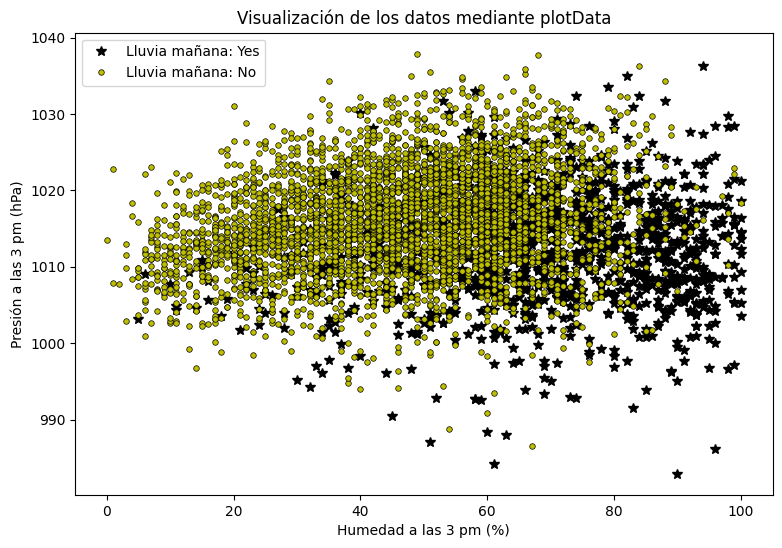

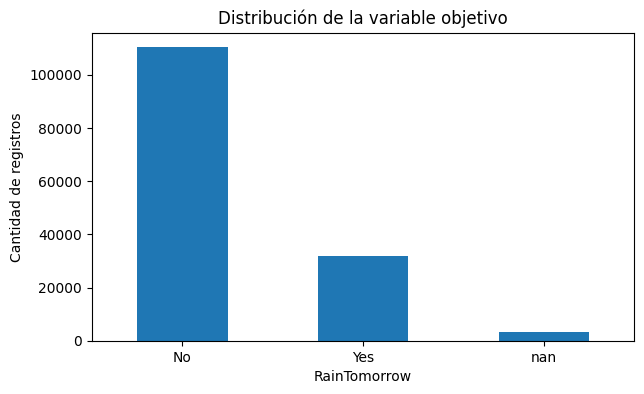

In [5]:
def plotData(X, y):
    # Grafica los ejemplos positivos y negativos con diferentes marcadores.
    fig = plt.figure(figsize=(9, 6))
    pos = y == 1
    neg = y == 0
    plt.plot(X[pos, 0], X[pos, 1], 'k*', lw=1, ms=7)
    plt.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=4, mec='k', mew=0.5)
    return fig

# Se toma una muestra para facilitar la visualización de un dataset grande.
muestra = df[['Humidity3pm', 'Pressure3pm', 'RainTomorrow']].dropna().sample(
    n=min(5000, len(df[['Humidity3pm', 'Pressure3pm', 'RainTomorrow']].dropna())),
    random_state=42
)
X_visual = muestra[['Humidity3pm', 'Pressure3pm']].to_numpy(dtype=float)
y_visual = muestra['RainTomorrow'].map({'No': 0, 'Yes': 1}).to_numpy()
plotData(X_visual, y_visual)
plt.xlabel('Humedad a las 3 pm (%)')
plt.ylabel('Presión a las 3 pm (hPa)')
plt.legend(['Lluvia mañana: Yes', 'Lluvia mañana: No'])
plt.title('Visualización de los datos mediante plotData')
plt.show()

plt.figure(figsize=(7, 4))
distribucion = df['RainTomorrow'].value_counts(dropna=False)
distribucion.plot(kind='bar')
plt.xlabel('RainTomorrow')
plt.ylabel('Cantidad de registros')
plt.title('Distribución de la variable objetivo')
plt.xticks(rotation=0)
plt.show()

## 3. Preprocesamiento con Pandas

Para que la regresión logística pueda trabajar con los datos, se seleccionan variables numéricas relacionadas con las condiciones meteorológicas.

Se utilizarán **13 propiedades predictoras**, por lo que se cumple `n ≥ 5`.

Las propiedades seleccionadas son:

`MinTemp`, `MaxTemp`, `Rainfall`, `WindGustSpeed`, `WindSpeed9am`, `WindSpeed3pm`, `Humidity9am`, `Humidity3pm`, `Pressure9am`, `Pressure3pm`, `Temp9am`, `Temp3pm` y `RainToday`.

`RainToday` es categórica y se transforma a 0/1. Los valores faltantes de las propiedades numéricas se reemplazan con la **mediana**, calculada posteriormente solamente con el conjunto de entrenamiento para evitar fuga de información.

La variable `RainTomorrow` se transforma a 0/1.

In [6]:
# Copia de trabajo
datos = df.copy()

# El objetivo debe estar disponible
datos = datos.dropna(subset=['RainTomorrow']).copy()

# Variable categórica binaria
datos['RainToday'] = datos['RainToday'].map({'No': 0, 'Yes': 1})

features = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
    'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
    'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday'
]

X_df = datos[features].copy()
y = datos['RainTomorrow'].map({'No': 0, 'Yes': 1}).astype(int).to_numpy()

print('Ejemplos disponibles después de eliminar objetivos faltantes:', len(datos))
print('Número de propiedades:', len(features))
display(X_df.head())


Ejemplos disponibles después de eliminar objetivos faltantes: 142193
Número de propiedades: 13


,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday
0,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,0.0
1,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,0.0
2,12.9,25.7,0.0,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,0.0
3,9.2,28.0,0.0,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,0.0
4,17.5,32.3,1.0,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,0.0


## 4. División 80% entrenamiento / 20% prueba

Se separan los datos antes de calcular estadísticas de normalización. De esta manera, los datos destinados a prueba **no participan en el entrenamiento**.

Se utiliza una división estratificada manual para conservar aproximadamente la misma proporción de clases en ambos conjuntos.

In [7]:
# Eliminar filas que no tengan RainToday antes de dividir
valid = X_df['RainToday'].notna().to_numpy()
X_df = X_df.loc[valid].reset_index(drop=True)
y = y[valid]

# Índices estratificados
idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]

np.random.shuffle(idx_0)
np.random.shuffle(idx_1)

n0_train = int(0.80 * len(idx_0))
n1_train = int(0.80 * len(idx_1))

train_idx = np.concatenate([idx_0[:n0_train], idx_1[:n1_train]])
test_idx = np.concatenate([idx_0[n0_train:], idx_1[n1_train:]])

np.random.shuffle(train_idx)
np.random.shuffle(test_idx)

X_train_df = X_df.iloc[train_idx].copy()
X_test_df = X_df.iloc[test_idx].copy()
y_train = y[train_idx]
y_test = y[test_idx]

print(f'Entrenamiento: {len(X_train_df)} ejemplos ({len(X_train_df)/len(X_df)*100:.2f}%)')
print(f'Prueba:        {len(X_test_df)} ejemplos ({len(X_test_df)/len(X_df)*100:.2f}%)')
print(f'Propiedades:   {X_train_df.shape[1]}')


Entrenamiento: 112628 ejemplos (80.00%)
Prueba:        28159 ejemplos (20.00%)
Propiedades:   13


## 5. Tratamiento de valores faltantes y normalización

Los valores faltantes de cada propiedad se reemplazan por la mediana del **conjunto de entrenamiento**. Después se aplica normalización estándar:

$$X_{norm} = \frac{X-\mu}{\sigma}$$

Los valores `μ` y `σ` se calculan exclusivamente con entrenamiento y luego se aplican tanto a entrenamiento como a prueba.

In [8]:
# Medianas calculadas SOLO con entrenamiento
medianas = X_train_df.median(numeric_only=True)

X_train_df = X_train_df.fillna(medianas)
X_test_df = X_test_df.fillna(medianas)

# Convertir a matrices NumPy
X_train_raw = X_train_df.to_numpy(dtype=float)
X_test_raw = X_test_df.to_numpy(dtype=float)

# Media y desviación estándar SOLO del entrenamiento
mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)

# Evitar división por cero
sigma[sigma == 0] = 1

X_train_norm = (X_train_raw - mu) / sigma
X_test_norm = (X_test_raw - mu) / sigma

# Agregar término de intercepción
X_train = np.concatenate([np.ones((len(X_train_norm), 1)), X_train_norm], axis=1)
X_test = np.concatenate([np.ones((len(X_test_norm), 1)), X_test_norm], axis=1)

print('Matriz X_train:', X_train.shape)
print('Matriz X_test: ', X_test.shape)
print('Vector y_train:', y_train.shape)
print('Vector y_test: ', y_test.shape)


Matriz X_train: (112628, 14)
Matriz X_test:  (28159, 14)
Vector y_train: (112628,)
Vector y_test:  (28159,)


## 6. Función sigmoidea

La hipótesis de la regresión logística es:

$$h_\theta(x)=g(\theta^Tx)$$

donde:

$$g(z)=\frac{1}{1+e^{-z}}$$

La sigmoidea transforma cualquier valor real en un valor entre 0 y 1, que puede interpretarse como la probabilidad estimada de que `RainTomorrow = 1`.

In [9]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

print('sigmoid(-10) =', sigmoid(-10))
print('sigmoid(0)  =', sigmoid(0))
print('sigmoid(10) =', sigmoid(10))


sigmoid(-10) = 4.5397868702434395e-05
sigmoid(0)  = 0.5
sigmoid(10) = 0.9999546021312976


## 7. Función de costo y gradiente

Para la clasificación binaria se utiliza la entropía cruzada:

$$J(\theta)=\frac{1}{m}\sum_{i=1}^{m}
[-y^{(i)}\log(h_\theta(x^{(i)}))
-(1-y^{(i)})\log(1-h_\theta(x^{(i)}))]$$

El gradiente permite determinar cómo modificar los parámetros `θ` para disminuir el costo.

In [10]:
def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta))
    eps = 1e-15
    h = np.clip(h, eps, 1 - eps)
    J = -(1 / m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return J

def calcularGradiente(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta))
    return (1 / m) * X.T.dot(h - y)

theta_inicial = np.zeros(X_train.shape[1])

print('Número de parámetros theta:', len(theta_inicial))
print('Costo inicial:', calcularCosto(theta_inicial, X_train, y_train))


Número de parámetros theta: 14
Costo inicial: 0.6931471805599453


## 8. Determinación de θ mediante descenso de gradiente

Se actualizan los parámetros mediante:

$$\theta := \theta - \alpha\frac{\partial J(\theta)}{\partial\theta}$$

Como el dataset es grande, se utiliza un número controlado de iteraciones. En cada iteración se registra el costo para comprobar gráficamente la convergencia del modelo.

In [11]:
def descensoGradiente(theta, X, y, alpha=0.05, num_iters=1500):
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        grad = calcularGradiente(theta, X, y)
        theta -= alpha * grad
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

alpha = 0.05
num_iters = 1500

theta, J_history = descensoGradiente(
    theta_inicial, X_train, y_train,
    alpha=alpha,
    num_iters=num_iters
)

print('Theta calculado:')
for i, valor in enumerate(theta):
    nombre = 'Intercepto' if i == 0 else features[i-1]
    print(f'{nombre:15s}: {valor:.6f}')

print('\nCosto inicial:', J_history[0])
print('Costo final:  ', J_history[-1])


Theta calculado:
Intercepto     : -1.769304
MinTemp        : 0.138762
MaxTemp        : -0.107274
Rainfall       : 0.080873
WindGustSpeed  : 0.658532
WindSpeed9am   : -0.079480
WindSpeed3pm   : -0.237616
Humidity9am    : 0.155890
Humidity3pm    : 1.111371
Pressure9am    : 0.067947
Pressure3pm    : -0.501809
Temp9am        : 0.083600
Temp3pm        : -0.123647
RainToday      : 0.194190

Costo inicial: 0.6837492637352495
Costo final:   0.370969039946079


## 9. Gráfico de convergencia del costo

El gráfico muestra el comportamiento de `J(θ)` durante el entrenamiento. Una disminución progresiva del costo indica que el algoritmo de descenso de gradiente está encontrando parámetros que mejoran la clasificación sobre los datos de entrenamiento.

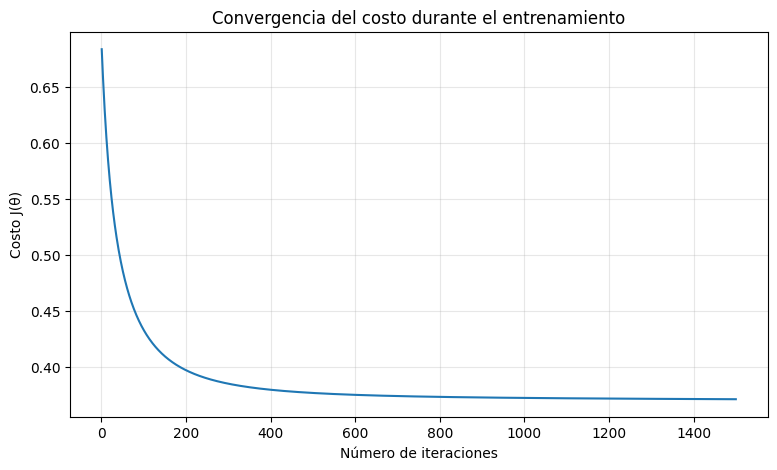

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(np.arange(1, len(J_history) + 1), J_history)
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J(θ)')
plt.title('Convergencia del costo durante el entrenamiento')
plt.grid(True, alpha=0.3)
plt.show()


## 10. Modelo de clasificación y predicciones

La probabilidad estimada se obtiene con:

$$P(RainTomorrow=1|x)=\sigma(\theta^Tx)$$

Se utiliza un umbral de 0.5:

- probabilidad ≥ 0.5 → `Yes` (1)
- probabilidad < 0.5 → `No` (0)

Las predicciones de prueba se calculan con datos que no fueron utilizados para determinar `θ`.

In [13]:
def predict_proba(theta, X):
    return sigmoid(X.dot(theta))

def predict(theta, X, threshold=0.5):
    return (predict_proba(theta, X) >= threshold).astype(int)

prob_test = predict_proba(theta, X_test)
y_pred = predict(theta, X_test)

print('Primeras 20 probabilidades y predicciones:')
resultado = pd.DataFrame({
    'Probabilidad_lluvia': prob_test[:20],
    'Prediccion': np.where(y_pred[:20] == 1, 'Yes', 'No'),
    'Real': np.where(y_test[:20] == 1, 'Yes', 'No')
})
display(resultado)


Primeras 20 probabilidades y predicciones:


,Probabilidad_lluvia,Prediccion,Real
0,0.207975,No,No
1,0.430970,No,No
2,0.329489,No,No
3,0.184228,No,No
4,0.287072,No,No
5,0.053874,No,No
6,0.216155,No,No
7,0.167737,No,Yes
8,0.125603,No,No
9,0.581330,Yes,No


## 11. Validación del modelo

Se evalúa el modelo tanto sobre entrenamiento como sobre prueba. La métrica principal será la exactitud (accuracy):

$$Accuracy=\frac{\text{predicciones correctas}}{\text{total de ejemplos}}$$

También se calcula la matriz de confusión para observar los aciertos y errores de cada clase.

In [14]:
def accuracy(y_real, y_pred):
    return np.mean(y_real == y_pred)

y_pred_train = predict(theta, X_train)
acc_train = accuracy(y_train, y_pred_train)
acc_test = accuracy(y_test, y_pred)

print(f'Precisión de entrenamiento: {acc_train * 100:.2f}%')
print(f'Precisión de prueba:        {acc_test * 100:.2f}%')

# Matriz de confusión
cm = pd.crosstab(
    pd.Series(y_test, name='Real'),
    pd.Series(y_pred, name='Predicción')
)

print('\nMatriz de confusión:')
display(cm)


Precisión de entrenamiento: 84.09%
Precisión de prueba:        84.29%

Matriz de confusión:


Predicción,0,1
Real,,
0,20771,1147
1,3278,2963


## 12. Precisión, sensibilidad y especificidad

Además de la exactitud, se calculan medidas que permiten interpretar mejor el comportamiento del clasificador.

- **Precisión (Precision):** de los casos que el modelo predijo como lluvia, cuántos fueron realmente lluvia.
- **Sensibilidad (Recall):** de los días en los que realmente llovió, cuántos detectó el modelo.
- **Especificidad:** de los días sin lluvia, cuántos clasificó correctamente.

In [15]:
tn = np.sum((y_test == 0) & (y_pred == 0))
fp = np.sum((y_test == 0) & (y_pred == 1))
fn = np.sum((y_test == 1) & (y_pred == 0))
tp = np.sum((y_test == 1) & (y_pred == 1))

precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0
specificity = tn / (tn + fp) if (tn + fp) else 0

metricas = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall / Sensibilidad', 'Especificidad'],
    'Valor': [acc_test, precision, recall, specificity]
})

display(metricas.style.format({'Valor': '{:.4f}'}))

print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')


,Métrica,Valor
0,Accuracy,0.8429
1,Precision,0.7209
2,Recall / Sensibilidad,0.4748
3,Especificidad,0.9477


TN=20771, FP=1147, FN=3278, TP=2963


## 13. Predicción de un caso del conjunto de prueba

A continuación se muestra un ejemplo real del conjunto de prueba. Se presentan las propiedades utilizadas, la probabilidad estimada y la clasificación obtenida.

In [16]:
i = 0

caso = X_test_df.iloc[i].copy()
probabilidad = prob_test[i]
prediccion = 'Yes' if y_pred[i] == 1 else 'No'
real = 'Yes' if y_test[i] == 1 else 'No'

display(caso.to_frame('Valor'))

print(f'Probabilidad estimada de lluvia mañana: {probabilidad:.4f}')
print(f'Predicción del modelo: {prediccion}')
print(f'Valor real:             {real}')


,Valor
MinTemp,16.9
MaxTemp,22.9
Rainfall,0.2
WindGustSpeed,41.0
WindSpeed9am,20.0
WindSpeed3pm,26.0
Humidity9am,86.0
Humidity3pm,62.0
Pressure9am,1016.2
Pressure3pm,1016.0


Probabilidad estimada de lluvia mañana: 0.2080
Predicción del modelo: No
Valor real:             No


## 14. Conclusión

El dataset `weatherAUS.csv` cumple las condiciones del ejercicio porque posee más de 20.000 ejemplos y más de 5 propiedades predictoras.

Se aplicó Pandas para preparar los datos, se separó el conjunto en **80% para entrenamiento y 20% para prueba**, y las estadísticas utilizadas para normalizar se obtuvieron únicamente del entrenamiento.

El modelo utiliza regresión logística binaria, determina los parámetros `θ` mediante descenso de gradiente y registra el costo en cada iteración. El gráfico de convergencia permite comprobar la evolución del entrenamiento.

Finalmente, el modelo se valida con datos que no participaron en el entrenamiento y se muestran predicciones, accuracy y matriz de confusión para demostrar su efectividad.